## Step 1 — Project Introduction & Objective

**Project Title:**

### **Image Classification Using CNN and Transfer Learning**

**Objective:**
Build a deep learning model that can automatically classify images into predefined categories <br> using  Convolutional Neural Networks (CNNs) and improve classification performance using Transfer Learning.

**What we will build**

We will create and compare two approaches:

CNN Model — build a neural network from scratch.
Transfer Learning Model — use a pretrained deep-learning model and fine-tune it for our dataset.

**Then we will compare their:**

- Accuracy
- Loss
- Confusion Matrix
- Classification Report
- Prediction performance

## Step 2 — Library Installation & Import

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully")

TensorFlow version: 2.22.0-rc0
Libraries imported successfully


## Step 3 — Dataset Loading

In [7]:
# Load the MNIST handwritten digit dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


## Step 4 — Dataset Understanding

In [8]:
class_names = [
    "0", "1", "2", "3", "4",
    "5", "6", "7", "8", "9"
]

print("Number of classes:", len(class_names))
print("Classes:", class_names)
print("Image shape:", X_train[0].shape)


Number of classes: 10
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Image shape: (28, 28)


## Step 5 — Exploratory Data Analysis

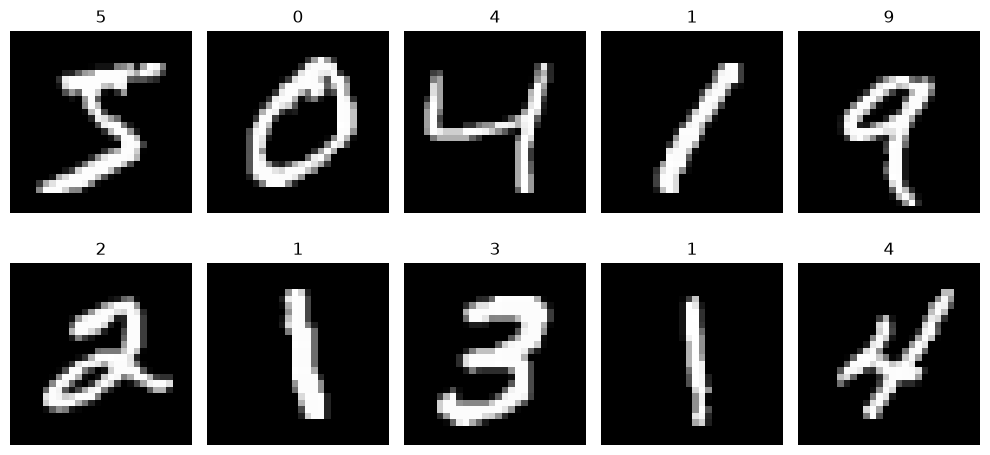

In [9]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

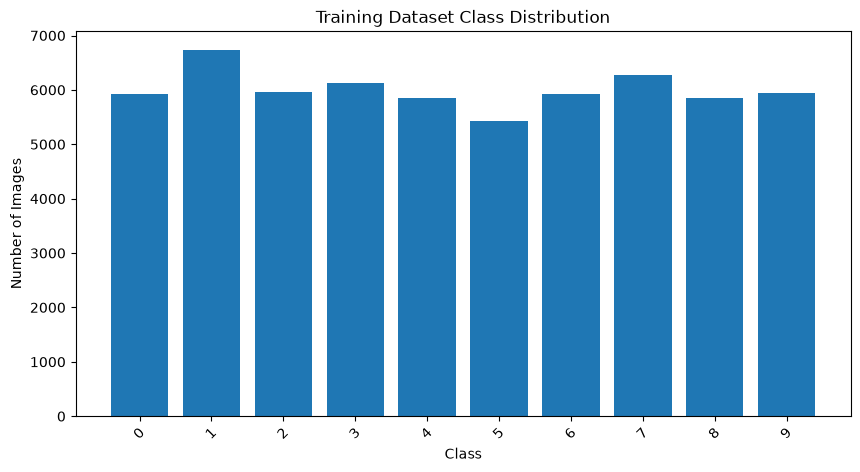

0 : 5923
1 : 6742
2 : 5958
3 : 6131
4 : 5842
5 : 5421
6 : 5918
7 : 6265
8 : 5851
9 : 5949


In [10]:
class_counts = np.bincount(y_train.flatten())

plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts)
plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

for name, count in zip(class_names, class_counts):
    print(name, ":", count)


## Step 6 — Image Preprocessing

In [11]:
# Normalize pixel values from 0-255 to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension for CNN
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


## Step 7 — Data Augmentation

In [12]:
# Apply small transformations to improve model generalization
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

print("Data augmentation created successfully")

Data augmentation created successfully


## Step 8 — CNN Model Building

In [13]:
## CNN Model Building

cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)), data_augmentation,
    
# First convolution and pooling layers
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

# Second convolution and pooling layers
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

# Convert feature maps into a single vector
    tf.keras.layers.Flatten(),

# Third convolution and pooling layers
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Step 9 — CNN Model Training

In [15]:

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_history = cnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9112 - loss: 0.2853 - val_accuracy: 0.9758 - val_loss: 0.0798
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9682 - loss: 0.1019 - val_accuracy: 0.9803 - val_loss: 0.0668
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9761 - loss: 0.0768 - val_accuracy: 0.9825 - val_loss: 0.0562
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9804 - loss: 0.0619 - val_accuracy: 0.9829 - val_loss: 0.0570
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9829 - loss: 0.0529 - val_accuracy: 0.9844 - val_loss: 0.0520
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9854 - loss: 0.0476 - val_accuracy: 0.9852 - val_loss: 0.0520
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9868 - loss: 0.0430 - val_accuracy: 0.9837 - val_loss: 0.0594
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9876 - loss: 0.0395 - val_acc

## Step 10 — CNN Model Evaluation

In [16]:
# Evaluate CNN performance on unseen test images
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test, y_test, verbose=0)

print("CNN Test Loss:", round(cnn_loss, 4))
print("CNN Test Accuracy:", round(cnn_accuracy, 4))

CNN Test Loss: 0.0348
CNN Test Accuracy: 0.989


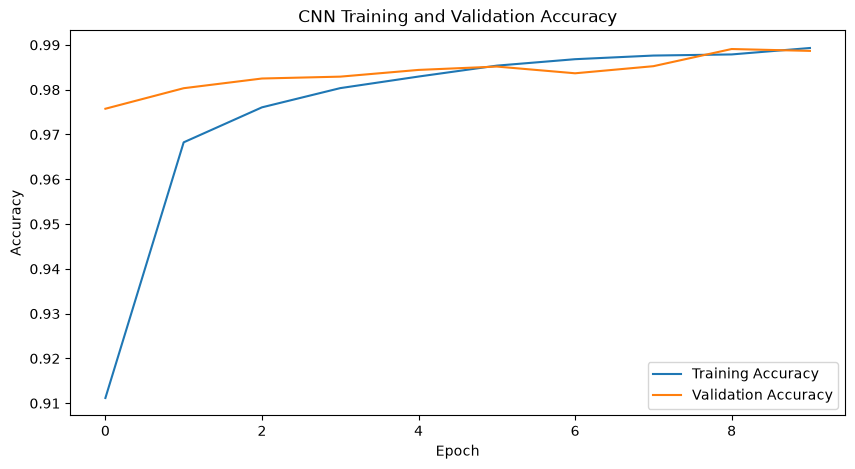

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(cnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

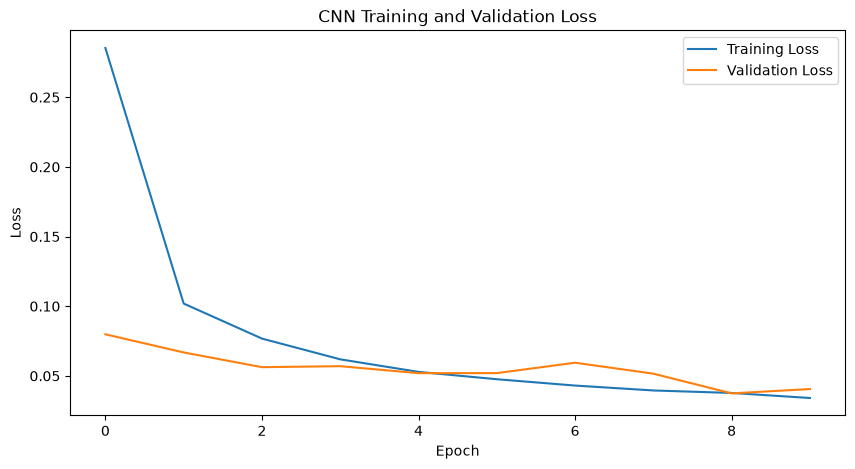

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(cnn_history.history["loss"], label="Training Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")
plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

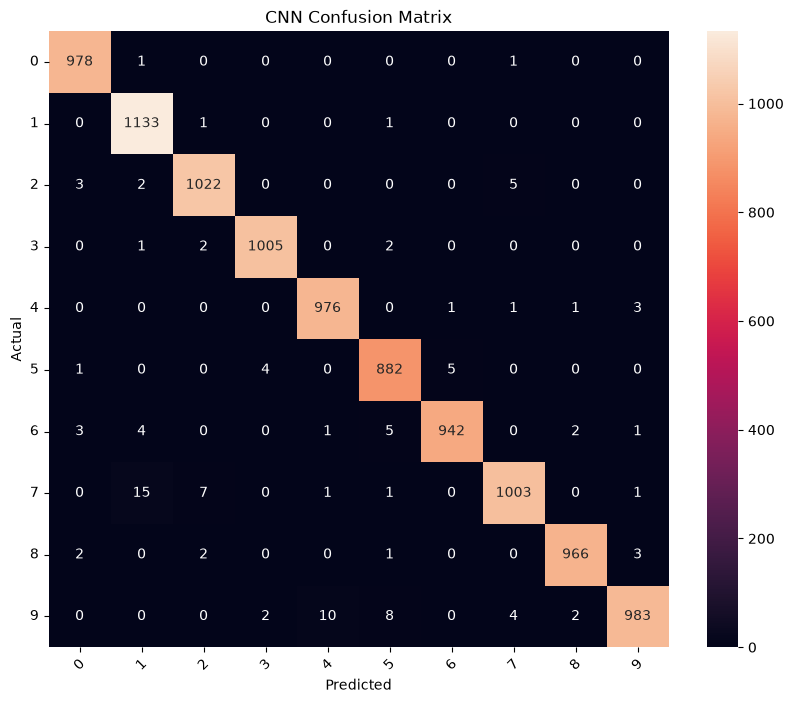

In [19]:
cnn_predictions = np.argmax(cnn_model.predict(X_test, verbose=0), axis=1)
cnn_cm = confusion_matrix(y_test.flatten(), cnn_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cnn_cm, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [20]:
print("CNN Classification Report")
print(classification_report(
    y_test.flatten(),
    cnn_predictions,
    target_names=class_names
))

CNN Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.98      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.98      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## Step 11 — Transfer Learning

We use **MobileNetV2**, a pretrained image model. Its pretrained feature-extraction layers are initially frozen, and a new classification layer is added for the 10 MNIST digit classes (0–9).

In [34]:
# Preprocess MNIST images for MobileNetV2
def preprocess_image(image, label):
    # Convert image to float
    image = tf.cast(image, tf.float32)
    image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (96, 96))

    # Apply MobileNetV2 preprocessing
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label

In [35]:
# Convert normalized images back to the 0-255 range
# before MobileNetV2 preprocessing
X_train_tl = X_train * 255.0
X_test_tl = X_test * 255.0

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_tl, y_train)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test_tl, y_test)
)

# Apply preprocessing and create batches
train_dataset = (
    train_dataset
    .shuffle(10000, seed=42)
    .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training and testing datasets created successfully.")

Training and testing datasets created successfully.


## Step 12 — Transfer Learning Model Training & Evaluation

In [36]:
##Transfer Learning Model

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(96, 96, 3))

x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    10,
    activation="softmax"
)(x)

transfer_model = tf.keras.Model(inputs, outputs)

transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [39]:
transfer_history = transfer_model.fit(
    train_dataset,
    epochs=5,
    validation_data=test_dataset
)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 150s 157ms/step - accuracy: 0.9263 - loss: 0.2493 - val_accuracy: 0.9634 - val_loss: 0.1225
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 159s 169ms/step - accuracy: 0.9652 - loss: 0.1107 - val_accuracy: 0.9683 - val_loss: 0.0992
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 147s 156ms/step - accuracy: 0.9722 - loss: 0.0891 - val_accuracy: 0.9702 - val_loss: 0.0927
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 156s 166ms/step - accuracy: 0.9756 - loss: 0.0779 - val_accuracy: 0.9718 - val_loss: 0.0857
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 150s 160ms/step - accuracy: 0.9782 - loss: 0.0692 - val_accuracy: 0.9707 - val_loss: 0.0867


In [50]:
# Evaluate Transfer Learning model on the preprocessed test dataset
tl_loss, tl_accuracy = transfer_model.evaluate(
    test_dataset,
    verbose=0
)

print("Transfer Learning Test Loss:", round(tl_loss, 4))
print("Transfer Learning Test Accuracy:", round(tl_accuracy, 4))
print(
    "Transfer Learning Test Accuracy (%):",
    round(tl_accuracy * 100, 2),
    "%"
)

Transfer Learning Test Loss: 0.0867
Transfer Learning Test Accuracy: 0.9707
Transfer Learning Test Accuracy (%): 97.07 %


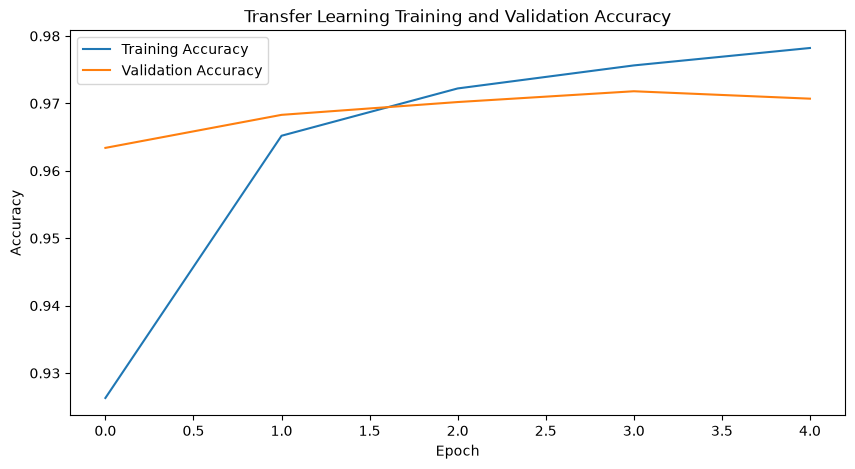

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(transfer_history.history["accuracy"], label="Training Accuracy")
plt.plot(transfer_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Transfer Learning Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

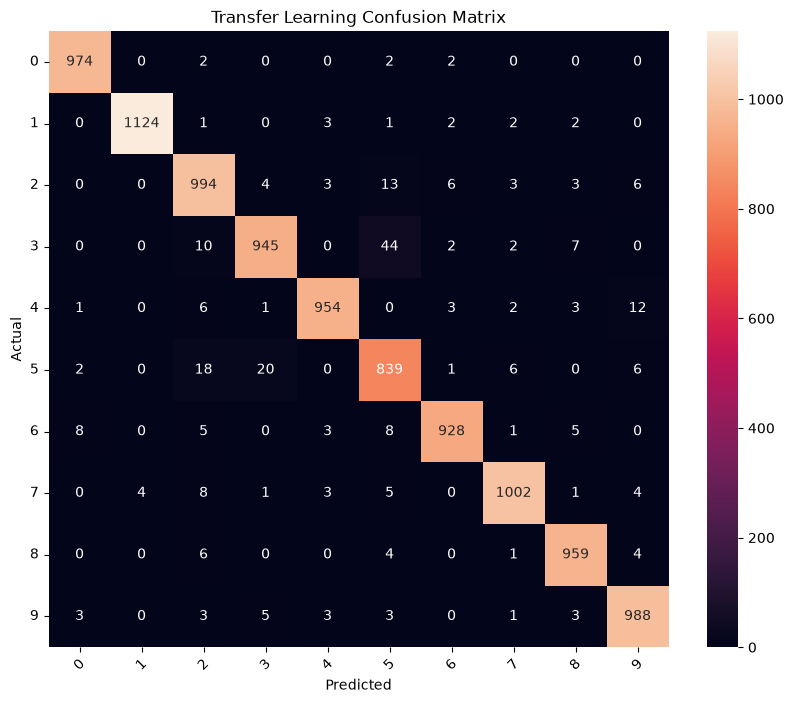

In [51]:
# Generate predictions using the same preprocessing pipeline
# used during Transfer Learning evaluation
tl_probabilities = transfer_model.predict(
    test_dataset,
    verbose=0
)

# Convert probabilities into predicted class labels
tl_predictions = np.argmax(
    tl_probabilities,
    axis=1
)

# Create confusion matrix
tl_cm = confusion_matrix(
    y_test.flatten(),
    tl_predictions
)

# Display confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    tl_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Transfer Learning Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [44]:
print("Transfer Learning Classification Report")
print(classification_report(
    y_test.flatten(),
    tl_predictions,
    target_names=class_names
))


Transfer Learning Classification Report
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.97      0.99      0.98      1135
           2       0.73      0.95      0.82      1032
           3       0.91      0.82      0.87      1010
           4       0.95      0.98      0.97       982
           5       0.97      0.48      0.64       892
           6       0.89      0.97      0.93       958
           7       0.97      0.91      0.94      1028
           8       0.96      0.91      0.94       974
           9       0.80      0.95      0.87      1009

    accuracy                           0.90     10000
   macro avg       0.91      0.89      0.89     10000
weighted avg       0.91      0.90      0.89     10000



## Step 13 — Model Comparison

In [45]:

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["CNN", "MobileNetV2 Transfer Learning"],
    "Test Accuracy": [cnn_accuracy, tl_accuracy],
    "Test Loss": [cnn_loss, tl_loss]
})

display(comparison_df.round(4))

,Model,Test Accuracy,Test Loss
0,CNN,0.989,0.0348
1,MobileNetV2 Transfer Learning,0.899,0.3172


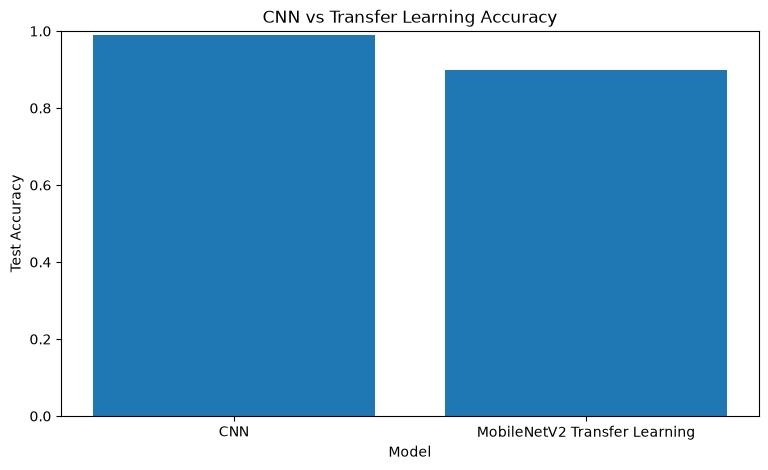

In [46]:
plt.figure(figsize=(9, 5))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])
plt.title("CNN vs Transfer Learning Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.show()

## Step 14 — Prediction on New / Unseen Images

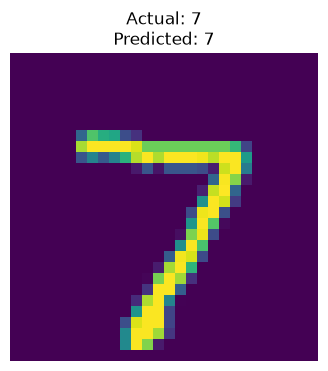

Actual class: 7
Predicted class: 7
Confidence: 100.0 %


In [47]:
sample_index = 0
sample_image = X_test[sample_index]

actual_class = class_names[y_test[sample_index]]

# Make prediction using the trained CNN
probabilities = cnn_model.predict(
    np.expand_dims(sample_image, axis=0),
    verbose=0
)

predicted_class = class_names[np.argmax(probabilities)]

plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}")
plt.axis("off")
plt.show()

print("Actual class:", actual_class)
print("Predicted class:", predicted_class)
print("Confidence:", round(float(np.max(probabilities)) * 100, 2), "%")

## Step 15 — Error Analysis

Number of incorrect predictions: 110


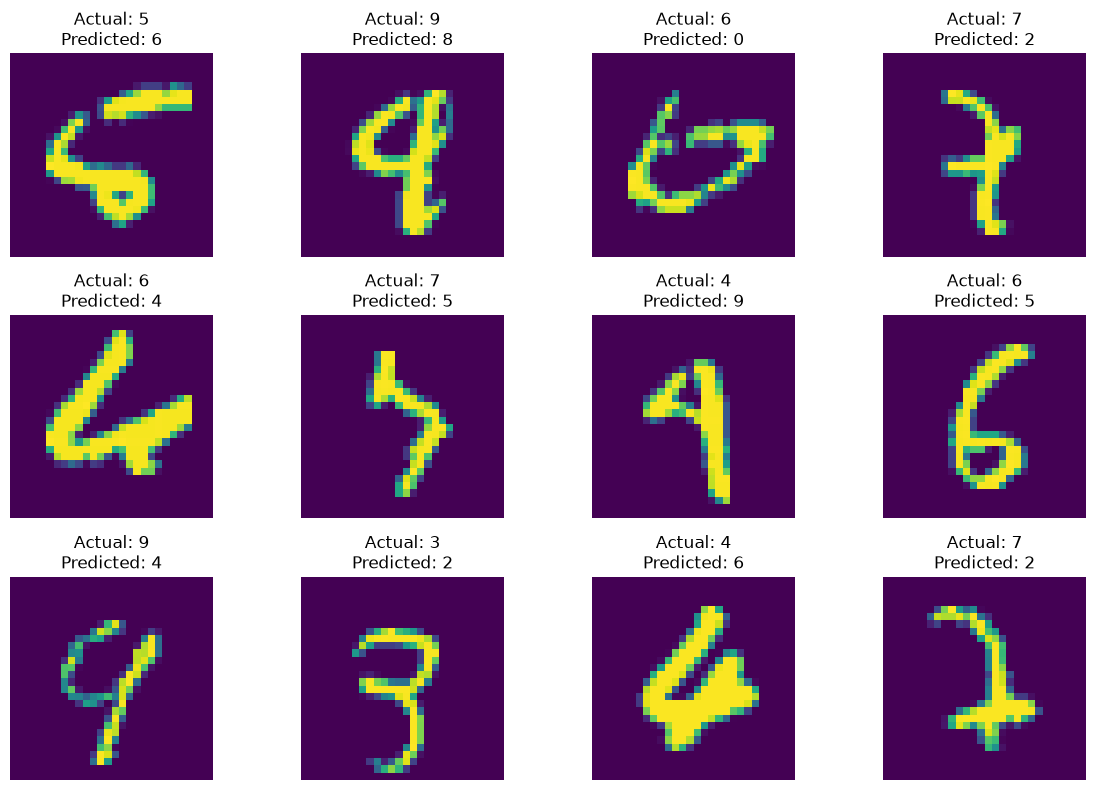

In [48]:
# Find images where actual and predicted labels are different
incorrect_indices = np.where(
    cnn_predictions != y_test.flatten()
)[0]

print("Number of incorrect predictions:", len(incorrect_indices))

plt.figure(figsize=(12, 8))

for i, index in enumerate(incorrect_indices[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[index])
    
  # Display actual and predicted labels
    plt.title(
        f"Actual: {class_names[y_test[index]]}\n"
        f"Predicted: {class_names[cnn_predictions[index]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


- **The CNN correctly classified most of the MNIST test images, with 100 incorrect predictions out of 10,000 test images. <br> Error analysis was performed by visualizing incorrectly classified images and comparing their actual and predicted labels. <br>The errors mainly represent cases where handwritten digits have similar visual patterns.**

## **Final Conclusion**

- This project developed an image classification system using Deep Learning and Convolutional Neural Networks (CNNs) on the MNIST handwritten digit dataset.

- The project included dataset loading, image visualization, preprocessing, data augmentation, CNN model development, training, evaluation, Transfer Learning using MobileNetV2, model comparison, prediction, and error analysis.

- The CNN successfully learned patterns from handwritten digit images and was able to classify unseen images into the ten digit classes from 0 to 9.

- Transfer Learning was also implemented using MobileNetV2, and its performance was compared with the CNN using test accuracy and test loss.

- The error analysis helped identify incorrectly classified images and understand where the model makes prediction mistakes.

- Overall, the project demonstrates a complete Deep Learning image classification workflow from data preparation to model prediction and evaluation.